In [ ]:
import pandas as pd

In [ ]:
st=pd.read_csv("/content/Streamflow_data.csv")

In [ ]:
st.describe()

,_id,SlNo,State LGD Code,District LGD Code,Latitude,Longitude,Manual Daily River Water Discharge (m3/sec)
count,265513.000000,265513.000000,265513.0,265513.000000,265513.000000,265513.000000,265513.000000
mean,132757.000000,132757.000000,21.0,359.389201,20.395986,84.762784,163.665104
std,76647.145349,76647.145349,0.0,7.814489,0.891238,1.369539,2462.777182
min,1.000000,1.000000,21.0,345.000000,18.493333,82.116389,0.000000
25%,66379.000000,66379.000000,21.0,353.000000,19.802222,83.613056,0.000000
50%,132757.000000,132757.000000,21.0,359.000000,20.376111,84.572222,6.396000
75%,199135.000000,199135.000000,21.0,365.000000,20.922500,86.072222,48.800000
max,265513.000000,265513.000000,21.0,373.000000,22.406667,87.320556,951089.000000


In [ ]:
st.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265513 entries, 0 to 265512
Data columns (total 21 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   _id                                          265513 non-null  int64  
 1   SlNo                                         265513 non-null  int64  
 2   Station                                      265513 non-null  object 
 3   Agency                                       265513 non-null  object 
 4   State LGD Code                               265513 non-null  int64  
 5   State                                        265513 non-null  object 
 6   District LGD Code                            265513 non-null  int64  
 7   District                                     265513 non-null  object 
 8   Tehsil                                       265513 non-null  object 
 9   Block                                        265513 non-nul

In [ ]:
df_stream = st[[
    'Data Acquisition Time',
    'Manual Daily River Water Discharge (m3/sec)',
    'Station',
    'Latitude',
    'Longitude'
]].copy()

In [ ]:
df_stream = df_stream.rename(columns={
    'Data Acquisition Time': 'date',
    'Manual Daily River Water Discharge (m3/sec)': 'discharge'
})

In [ ]:
df_stream['date'] = pd.to_datetime(df_stream['date'], dayfirst=True)

In [ ]:
df_stream = df_stream.sort_values('date')

In [ ]:
df_stream.head()

,date,discharge,Station,Latitude,Longitude
0,2001-01-01 06:00:00,0.0,Badapandusar,20.151111,85.180833
218469,2001-01-01 06:00:00,0.0,Rampur,21.732222,84.018333
260254,2001-01-01 06:00:00,0.0,Tumulibud,21.896667,84.031389
232290,2001-01-01 06:00:00,0.0,Takara,20.376111,84.778889
27546,2001-01-01 06:00:00,0.0,Bansajal,21.099722,84.252222


In [ ]:
df_stream.tail()

,date,discharge,Station,Latitude,Longitude
206324,2021-12-27 08:30:00,0.0,Pipalpankha,19.802222,84.356667
206325,2021-12-28 08:30:00,0.0,Pipalpankha,19.802222,84.356667
206326,2021-12-29 08:30:00,0.0,Pipalpankha,19.802222,84.356667
206327,2021-12-30 08:30:00,0.0,Pipalpankha,19.802222,84.356667
206328,2021-12-31 08:30:00,0.0,Pipalpankha,19.802222,84.356667


In [ ]:
df_stream.info()

<class 'pandas.core.frame.DataFrame'>
Index: 265513 entries, 0 to 206328
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   date       265513 non-null  datetime64[ns]
 1   discharge  265513 non-null  float64       
 2   Station    265513 non-null  object        
 3   Latitude   265513 non-null  float64       
 4   Longitude  265513 non-null  float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 12.2+ MB


In [ ]:
df_stream.describe()

,date,discharge,Latitude,Longitude
count,265513,265513.000000,265513.000000,265513.000000
mean,2010-11-13 08:54:52.371899136,163.665104,20.395986,84.762784
min,2001-01-01 06:00:00,0.000000,18.493333,82.116389
25%,2005-10-10 06:00:00,0.000000,19.802222,83.613056
50%,2010-11-13 08:00:00,6.396000,20.376111,84.572222
75%,2015-10-04 09:00:00,48.800000,20.922500,86.072222
max,2021-12-31 08:30:00,951089.000000,22.406667,87.320556
std,NaN,2462.777182,0.891238,1.369539


In [ ]:
df_streamflow = df_stream[
    (df_stream['date'] >= '2010-01-01') &
    (df_stream['date'] <= '2020-12-31')
].copy()

In [ ]:
df_streamflow['date'].min(), df_streamflow['date'].max()

(Timestamp('2010-01-01 00:09:00'), Timestamp('2020-12-30 10:30:00'))

In [ ]:
df_streamflow.size

687310

In [ ]:
df_streamflow.head()

,date,discharge,Station,Latitude,Longitude
94879,2010-01-01 00:09:00,863.000,Indupur,20.611111,86.403333
235577,2010-01-01 06:00:00,0.247,Takara,20.376111,84.778889
3287,2010-01-01 06:00:00,0.000,Badapandusar,20.151111,85.180833
56908,2010-01-01 07:00:00,0.335,Bisipada,20.395278,83.226667
188680,2010-01-01 08:00:00,0.000,Nimapada,20.055278,86.021111


In [ ]:
df_streamflow['date'] = df_streamflow['date'].dt.date

# aggregate to daily per station
df_stream_daily = df_streamflow.groupby(
    ['Station', 'date']
)['discharge'].mean().reset_index()

In [ ]:
df_streamflow.describe()

,discharge,Latitude,Longitude
count,137462.000000,137462.000000,137462.000000
mean,158.676696,20.394073,84.781322
std,3287.437520,0.894432,1.372638
min,0.000000,18.493333,82.116389
25%,0.000000,19.802222,83.613056
50%,4.136000,20.376111,84.572222
75%,41.148000,20.922500,86.072222
max,951089.000000,22.406667,87.320556


In [ ]:
df_stream_daily.head()

,Station,date,discharge
0,Badapandusar,2010-01-01,0.0
1,Badapandusar,2010-01-02,0.0
2,Badapandusar,2010-01-03,0.0
3,Badapandusar,2010-01-04,0.0
4,Badapandusar,2010-01-05,0.0


In [ ]:
df_stream_daily.describe()

,discharge
count,136973.000000
mean,159.110335
std,3293.289761
min,0.000000
25%,0.000000
50%,4.100000
75%,41.254000
max,951089.000000


In [ ]:
df_stream_daily['Station'].value_counts().head(10)

,count
Station,
Badapandusar,4017
Bahalda,4017
Takara,4017
Khanditar,4017
Indupur,4017
Cuttack,4017
Bisipada,4017
Naraj,4017
Tarapur,4017


In [ ]:
df_station = df_stream_daily[
    df_stream_daily['Station'] == 'Naraj'
].copy()

In [ ]:
df_station.head()

,date,discharge
92268,2010-01-01,186.74
92269,2010-01-02,201.70
92270,2010-01-03,203.13
92271,2010-01-04,205.31
92272,2010-01-05,194.24


# Naraj Station choosen

In [ ]:
df_station = df_station[['date', 'discharge']]

# ensure datetime
df_station['date'] = pd.to_datetime(df_station['date'])

In [ ]:
df_station.reset_index(drop=['index'])

,date,discharge
0,2010-01-01,186.74
1,2010-01-02,201.70
2,2010-01-03,203.13
3,2010-01-04,205.31
4,2010-01-05,194.24
...,...,...
4012,2020-12-26,209.66
4013,2020-12-27,209.66
4014,2020-12-28,209.66
4015,2020-12-29,209.66


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4018 entries, 0 to 4017
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4018 non-null   datetime64[ns]
 1   rainfall_mm    4018 non-null   float32       
 2   temperature_C  4018 non-null   float32       
dtypes: datetime64[ns](1), float32(2)
memory usage: 62.9 KB


In [ ]:
df_final = pd.merge(df, df_station, on='date', how='inner')

In [ ]:
df_final.head()

,date,rainfall_mm,temperature_C,discharge
0,2010-01-01,0.022545,17.620300,186.74
1,2010-01-02,0.000027,16.891205,201.70
2,2010-01-03,0.000001,17.301025,203.13
3,2010-01-04,0.000062,18.734985,205.31
4,2010-01-05,0.000019,18.316193,194.24


In [ ]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4017 entries, 0 to 4016
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           4017 non-null   datetime64[ns]
 1   rainfall_mm    4017 non-null   float32       
 2   temperature_C  4017 non-null   float32       
 3   discharge      4017 non-null   float64       
dtypes: datetime64[ns](1), float32(2), float64(1)
memory usage: 94.3 KB


In [ ]:
df_final.describe()

,date,rainfall_mm,temperature_C,discharge
count,4017,4017.000000,4017.000000,4017.000000
mean,2015-07-02 00:00:00.000000256,4.331058,26.054813,2059.732532
min,2010-01-01 00:00:00,0.000000,14.914246,0.000000
25%,2012-10-01 00:00:00,0.021707,23.201782,177.670000
50%,2015-07-02 00:00:00,0.690111,26.669708,333.490000
75%,2018-04-01 00:00:00,5.998534,28.472656,1569.320000
max,2020-12-30 00:00:00,60.209839,35.738953,161104.940000
std,NaN,7.188893,3.983835,5813.783625


In [ ]:
df_final.to_csv("Final_dataset.csv", index=False)

In [ ]:
df_station.to_csv("Naraj_station.csv", index=False)

In [ ]:
import pandas as pd

In [ ]:
df_final=pd.read_csv("/content/Final_dataset.csv")

In [ ]:
df_final.head()

,date,rainfall_mm,temperature_C,discharge
0,2010-01-01,0.022545,17.620300,186.74
1,2010-01-02,0.000027,16.891205,201.70
2,2010-01-03,0.000001,17.301025,203.13
3,2010-01-04,0.000062,18.734985,205.31
4,2010-01-05,0.000019,18.316193,194.24


In [ ]:
df = df_final.copy()

In [ ]:
df.describe()

,rainfall_mm,temperature_C,discharge
count,4017.000000,4017.000000,4017.000000
mean,4.331057,26.054814,2059.732532
std,7.188897,3.983833,5813.783625
min,0.000000,14.914246,0.000000
25%,0.021707,23.201782,177.670000
50%,0.690111,26.669708,333.490000
75%,5.998534,28.472656,1569.320000
max,60.209840,35.738953,161104.940000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4017 entries, 0 to 4016
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4017 non-null   object 
 1   rainfall_mm    4017 non-null   float64
 2   temperature_C  4017 non-null   float64
 3   discharge      4017 non-null   float64
dtypes: float64(3), object(1)
memory usage: 125.7+ KB


In [ ]:
df[df['discharge'] > 100000]

,date,rainfall_mm,temperature_C,discharge
2413,2016-08-10,18.162317,26.717041,155506.00
2414,2016-08-11,17.137184,26.930206,157789.14
2415,2016-08-12,11.511691,27.442200,161104.94


# EDA

In [ ]:
import matplotlib.pyplot as plt

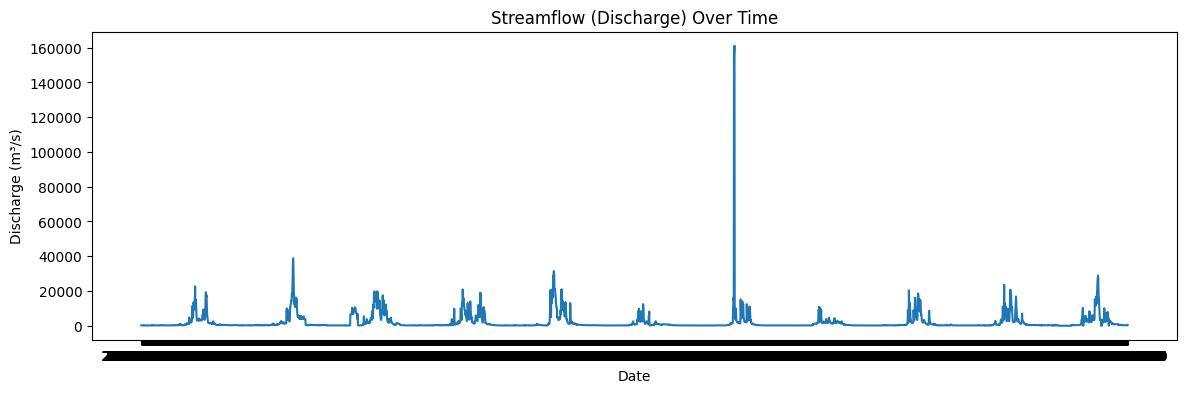

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(df['date'], df['discharge'])
plt.title("Streamflow (Discharge) Over Time")
plt.xlabel("Date")
plt.ylabel("Discharge (m³/s)")
plt.show()

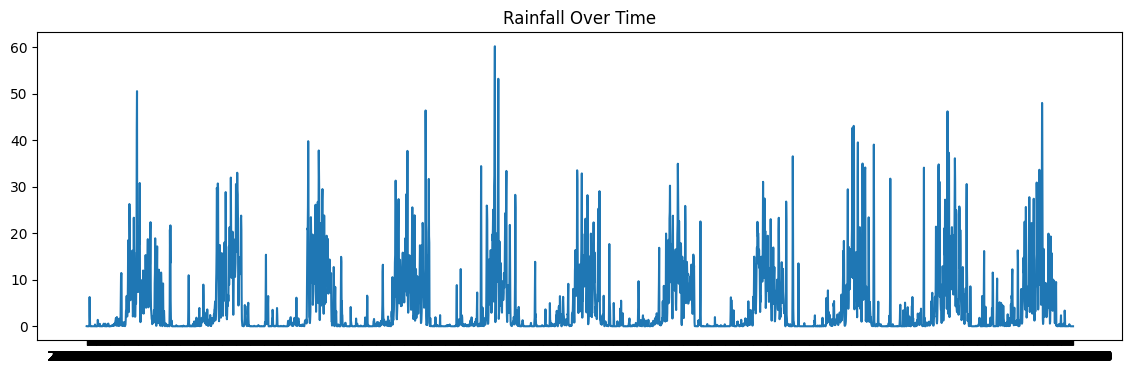

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(df['date'], df['rainfall_mm'])
plt.title("Rainfall Over Time")
plt.show()

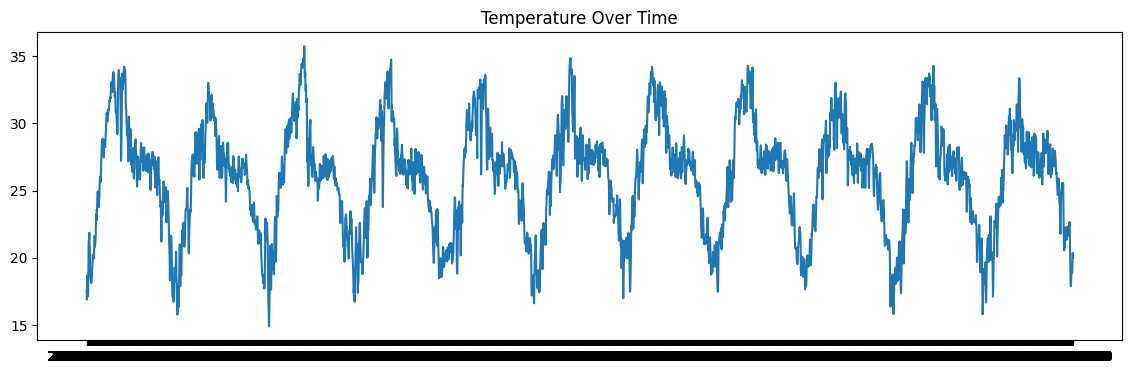

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(df['date'], df['temperature_C'])
plt.title("Temperature Over Time")
plt.show()

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['month'] = df['date'].dt.month

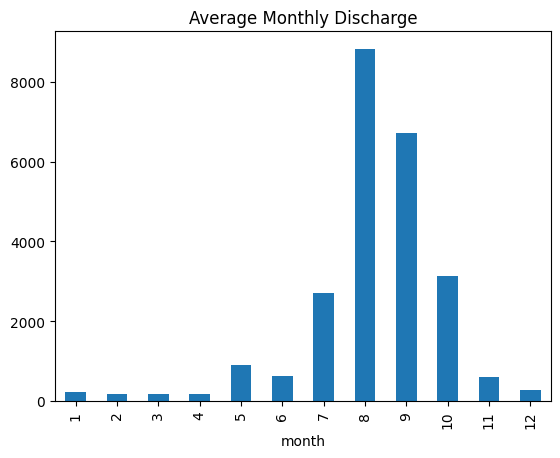

In [ ]:
df.groupby('month')['discharge'].mean().plot(kind='bar')
plt.title("Average Monthly Discharge")
plt.show()

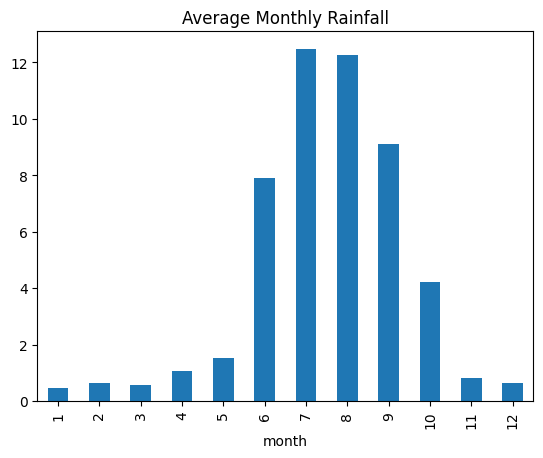

In [ ]:
df.groupby('month')['rainfall_mm'].mean().plot(kind='bar')
plt.title("Average Monthly Rainfall")
plt.show()

In [ ]:
df['rain_lag1'] = df['rainfall_mm'].shift(1)
df['rain_lag2'] = df['rainfall_mm'].shift(2)
df['rain_lag3'] = df['rainfall_mm'].shift(3)
df['rain_lag5'] = df['rainfall_mm'].shift(5)

In [ ]:
df.head()

,date,rainfall_mm,temperature_C,discharge,month,rain_lag1,rain_lag2,rain_lag3,rain_lag5
0,2010-01-01,0.022545,17.620300,186.74,1,NaN,NaN,NaN,NaN
1,2010-01-02,0.000027,16.891205,201.70,1,0.022545,NaN,NaN,NaN
2,2010-01-03,0.000001,17.301025,203.13,1,0.000027,0.022545,NaN,NaN
3,2010-01-04,0.000062,18.734985,205.31,1,0.000001,0.000027,0.022545,NaN
4,2010-01-05,0.000019,18.316193,194.24,1,0.000062,0.000001,0.000027,NaN


In [ ]:
df[['rainfall_mm', 'rain_lag1', 'rain_lag2', 'rain_lag3', 'rain_lag5', 'discharge']].corr()

,rainfall_mm,rain_lag1,rain_lag2,rain_lag3,rain_lag5,discharge
rainfall_mm,1.000000,0.789480,0.540848,0.440043,0.441383,0.257995
rain_lag1,0.789480,1.000000,0.789461,0.540806,0.430181,0.302609
rain_lag2,0.540848,0.789461,1.000000,0.789442,0.439941,0.347328
rain_lag3,0.440043,0.540806,0.789442,1.000000,0.540723,0.388452
rain_lag5,0.441383,0.430181,0.439941,0.540723,1.000000,0.417481
discharge,0.257995,0.302609,0.347328,0.388452,0.417481,1.000000


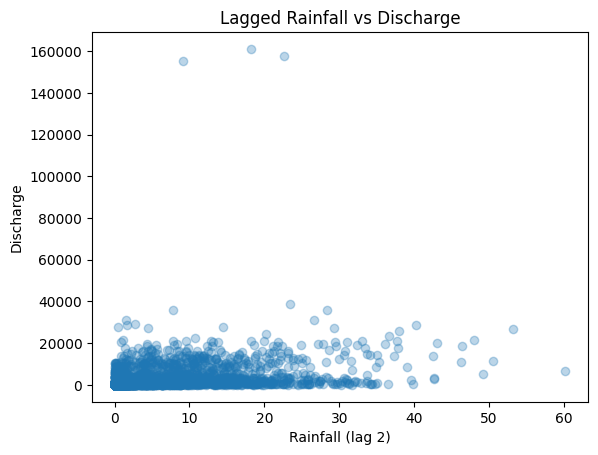

In [ ]:
plt.scatter(df['rain_lag2'], df['discharge'], alpha=0.3)
plt.xlabel("Rainfall (lag 2)")
plt.ylabel("Discharge")
plt.title("Lagged Rainfall vs Discharge")
plt.show()

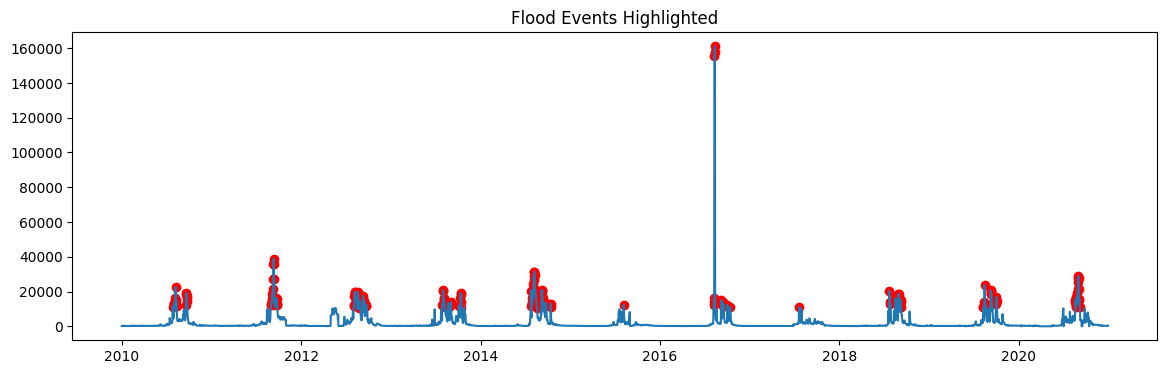

In [ ]:
threshold = df['discharge'].quantile(0.95)

plt.figure(figsize=(14,4))
plt.plot(df['date'], df['discharge'])
plt.scatter(df['date'][df['discharge'] > threshold],
            df['discharge'][df['discharge'] > threshold],
            color='red')
plt.title("Flood Events Highlighted")
plt.show()

In [ ]:
df.to_csv("new_final_ds.csv", index=False)

In [ ]:
df_fe = df.copy()

In [ ]:
df_fe['rain_lag1'] = df_fe['rainfall_mm'].shift(1)
df_fe['rain_lag2'] = df_fe['rainfall_mm'].shift(2)
df_fe['rain_lag3'] = df_fe['rainfall_mm'].shift(3)
df_fe['rain_lag5'] = df_fe['rainfall_mm'].shift(5)

In [ ]:
df_fe['discharge_lag1'] = df_fe['discharge'].shift(1)
df_fe['discharge_lag2'] = df_fe['discharge'].shift(2)

In [ ]:
df_fe['rain_3day'] = df_fe['rainfall_mm'].rolling(3).sum()
df_fe['rain_7day'] = df_fe['rainfall_mm'].rolling(7).sum()

In [ ]:
df_fe['month'] = df_fe['date'].dt.month
df_fe['day_of_year'] = df_fe['date'].dt.dayofyear

In [ ]:
threshold_rain = df_fe['rainfall_mm'].quantile(0.95)
df_fe['heavy_rain'] = (df_fe['rainfall_mm'] > threshold_rain).astype(int)

In [ ]:
threshold_flow = df_fe['discharge'].quantile(0.95)
df_fe['high_flow'] = (df_fe['discharge'] > threshold_flow).astype(int)

In [ ]:
df_fe = df_fe.dropna().reset_index(drop=True)

In [ ]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4011 entries, 0 to 4010
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            4011 non-null   datetime64[ns]
 1   rainfall_mm     4011 non-null   float64       
 2   temperature_C   4011 non-null   float64       
 3   discharge       4011 non-null   float64       
 4   month           4011 non-null   int32         
 5   rain_lag1       4011 non-null   float64       
 6   rain_lag2       4011 non-null   float64       
 7   rain_lag3       4011 non-null   float64       
 8   rain_lag5       4011 non-null   float64       
 9   discharge_lag1  4011 non-null   float64       
 10  discharge_lag2  4011 non-null   float64       
 11  rain_3day       4011 non-null   float64       
 12  rain_7day       4011 non-null   float64       
 13  day_of_year     4011 non-null   int32         
 14  heavy_rain      4011 non-null   int64         
 15  high

In [ ]:
df_model = df_fe.drop(columns=['date', 'high_flow'])

In [ ]:
df_model.isnull().sum()

,0
rainfall_mm,0
temperature_C,0
discharge,0
month,0
rain_lag1,0
rain_lag2,0
rain_lag3,0
rain_lag5,0
discharge_lag1,0
discharge_lag2,0


In [ ]:
df_model.to_csv("featured_final_ds.csv", index=False)

In [ ]:
import pandas as pd

In [ ]:
df_model=pd.read_csv("/content/featured_final_ds.csv")

In [ ]:
df_model.head()

,rainfall_mm,temperature_C,discharge,month,rain_lag1,rain_lag2,rain_lag3,rain_lag5,discharge_lag1,discharge_lag2,rain_3day,rain_7day,day_of_year,heavy_rain
0,0.000012,17.364716,204.53,1,0.001258,0.000019,0.000062,0.000027,190.66,194.24,0.001289,0.023924,7,0
1,0.007864,18.989563,188.34,1,0.000012,0.001258,0.000019,0.000001,204.53,190.66,0.009134,0.009243,8,0
2,0.009389,20.977448,182.56,1,0.007864,0.000012,0.001258,0.000062,188.34,204.53,0.017265,0.018605,9,0
3,0.085115,21.387970,190.55,1,0.009389,0.007864,0.000012,0.000019,182.56,188.34,0.102367,0.103718,10,0
4,0.013354,21.371277,378.63,1,0.085115,0.009389,0.007864,0.001258,190.55,182.56,0.107857,0.117010,11,0


In [ ]:
X = df_model.drop(columns=['discharge'])
y = df_model['discharge']

In [ ]:
split = int(0.8 * len(df_model))

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [ ]:
X_train.shape, X_test.shape

((3208, 13), (803, 13))

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, n_jobs=-1,
                      random_state=42)

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 3080.130384113051


In [ ]:
def NSE(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred)**2) /
                np.sum((y_true - np.mean(y_true))**2))

nse = NSE(y_test.values, y_pred)
print("NSE:", nse)

NSE: 0.36875615865274514


In [ ]:
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

rf.fit(X_train, y_train_log)

y_pred_log = rf.predict(X_test)
y_pred = np.expm1(y_pred_log)

In [ ]:
rmse = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
print("RMSE:", rmse)

RMSE: 1.5097143471984118


In [ ]:
nse_log= NSE(y_test_log.values, y_pred_log)
print("NSE:", nse_log)

NSE: 0.5322417556227188


In [ ]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
nse = NSE(y_test.values, y_pred)

print("RMSE:", rmse)
print("NSE:", nse)

RMSE: 1352.4886837201084
NSE: 0.8782900084317


In [ ]:
import matplotlib.pyplot as plt

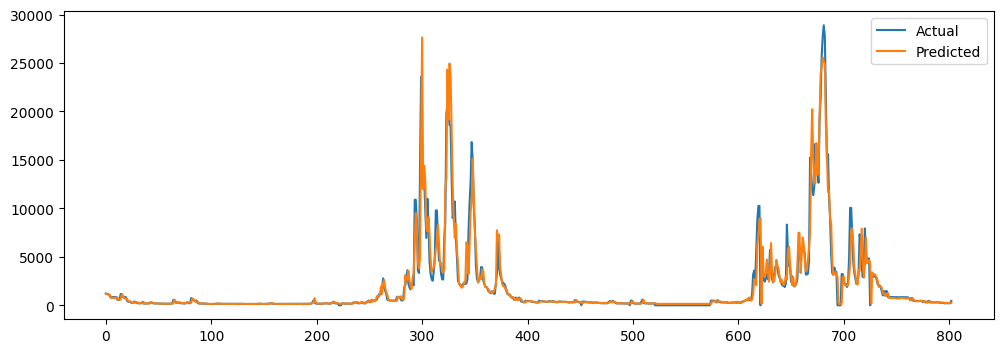

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.show()

In [ ]:
split_index = int(len(X) * 0.8)

In [ ]:
X_no_lag = X.drop(columns=['discharge_lag1', 'discharge_lag2'])

X_train2 = X_no_lag.iloc[:split_index]
X_test2  = X_no_lag.iloc[split_index:]

rf.fit(X_train2, y_train_log)

y_pred_log2 = rf.predict(X_test2)
y_pred2 = np.expm1(y_pred_log2)

rmse2 = np.sqrt(mean_squared_error(y_test, y_pred2))
nse2 = NSE(y_test.values, y_pred2)

print("RMSE:", rmse2)
print("NSE:", nse2)

RMSE: 2447.1450538865274
NSE: 0.6015458285478716


In [ ]:
!pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)

In [ ]:
shap_values = explainer.shap_values(X_test)

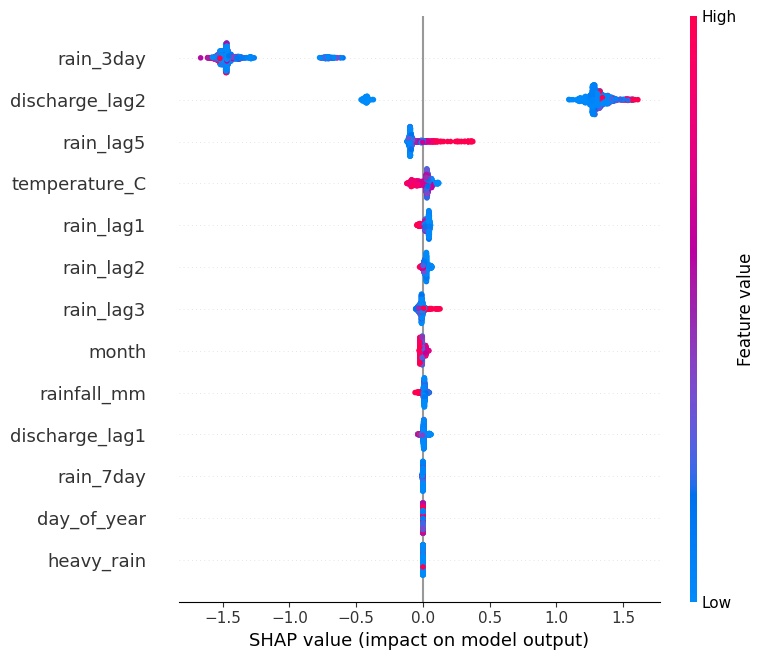

In [ ]:
shap.summary_plot(shap_values, X_test)

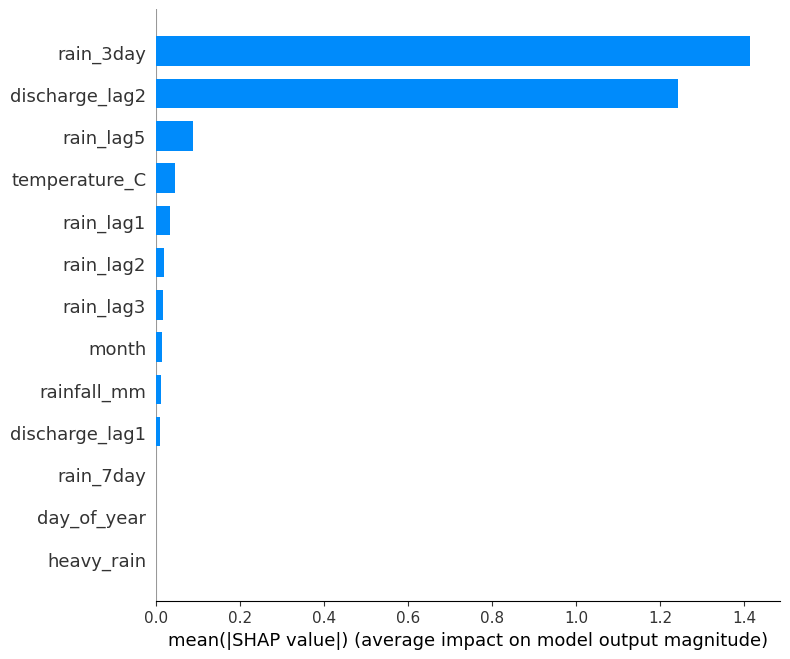

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
!pip install lightgbm

In [ ]:
import lightgbm as lgb

In [ ]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=25,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgb_model.fit(X_train, y_train_log)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000323 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2820
[LightGBM] [Info] Number of data points in the train set: 3208, number of used features: 13
[LightGBM] [Info] Start training from score 6.354716
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03, max_depth=5,
              n_estimators=1000, num_leaves=25, random_state=42, subsample=0.8)

In [ ]:
y_pred_log_lgb = lgb_model.predict(X_test)
y_pred_lgb = np.expm1(y_pred_log_lgb)

In [ ]:
rmse_lgb = np.sqrt(mean_squared_error(y_test, y_pred_lgb))
nse_lgb = NSE(y_test.values, y_pred_lgb)

print("RMSE:", rmse_lgb)
print("NSE:", nse_lgb)

RMSE: 1569.7875867472355
NSE: 0.8360389339745348


In [ ]:
y_train_pred_log = lgb_model.predict(X_train)
y_train_pred = np.expm1(y_train_pred_log)

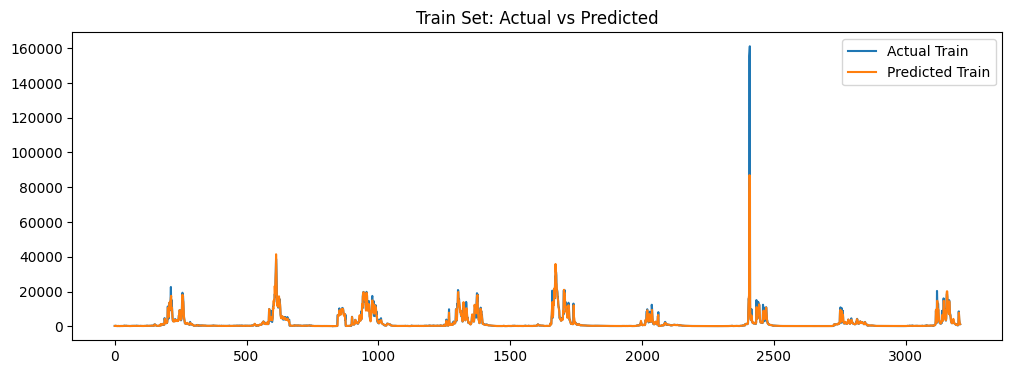

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_train.values, label='Actual Train')
plt.plot(y_train_pred, label='Predicted Train')
plt.title("Train Set: Actual vs Predicted")
plt.legend()
plt.show()

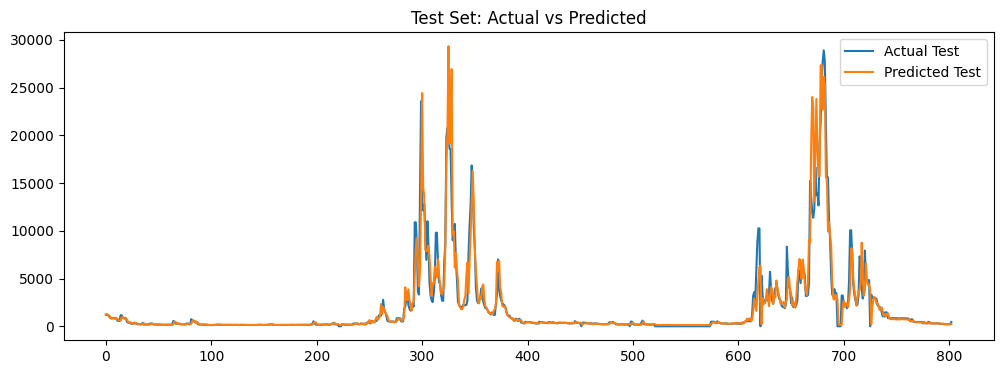

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(y_test.values, label='Actual Test')
plt.plot(y_pred_lgb, label='Predicted Test')
plt.title("Test Set: Actual vs Predicted")
plt.legend()
plt.show()

In [ ]:
# Train metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
nse_train = NSE(y_train.values, y_train_pred)

# Test metrics (already computed)
print("Train RMSE:", rmse_train)
print("Train NSE:", nse_train)

print("Test RMSE:", rmse_lgb)
print("Test NSE:", nse_lgb)

Train RMSE: 2448.2898113284164
Train NSE: 0.8444431251737698
Test RMSE: 1569.7875867472355
Test NSE: 0.8360389339745348


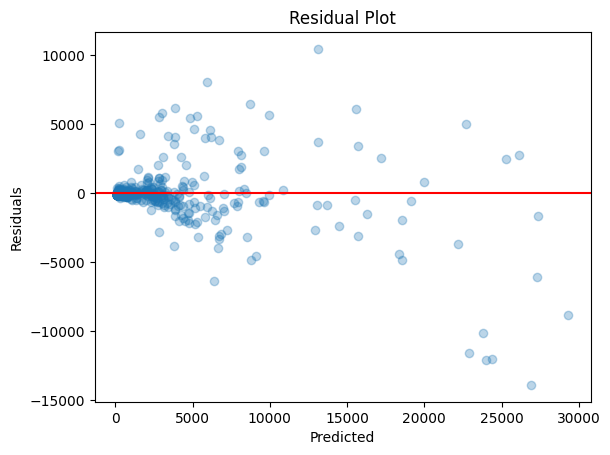

In [ ]:
residuals = y_test - y_pred_lgb

plt.scatter(y_pred_lgb, residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [ ]:
threshold = y_test.quantile(0.90)   # top 10% flows

In [ ]:
mask = y_test > threshold

y_test_peak = y_test[mask]
y_pred_peak = y_pred[mask]

In [ ]:
nse_peak = NSE(y_test_peak.values, y_pred_peak)
print("Peak NSE:", nse_peak)

Peak NSE: 0.5695906502091665


In [ ]:
rmse_peak = np.sqrt(mean_squared_error(y_test_peak, y_pred_peak))
print("Peak RMSE:", rmse_peak)

Peak RMSE: 3826.9236331299617


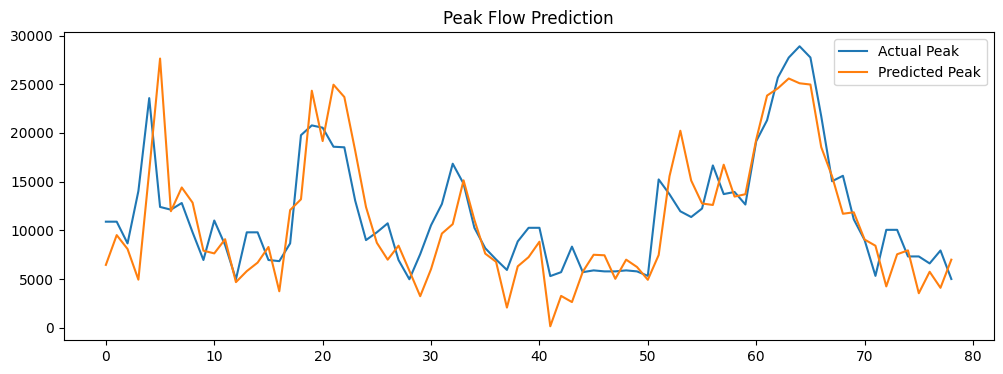

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(y_test_peak.values, label='Actual Peak')
plt.plot(y_pred_peak, label='Predicted Peak')
plt.legend()
plt.title("Peak Flow Prediction")
plt.show()

# LSTM


In [ ]:
df_lstm = df_model.copy()

In [ ]:
features = [
    'rainfall_mm',
    'temperature_C',
    'rain_3day',
    'rain_7day',
    'discharge_lag1',
    'discharge_lag2'
]

target = 'discharge'

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(df_lstm[features])
y_scaled = scaler_y.fit_transform(df_lstm[[target]])

In [ ]:
window = 7

X_seq = []
y_seq = []

for i in range(window, len(X_scaled)):
    X_seq.append(X_scaled[i-window:i])
    y_seq.append(y_scaled[i])

import numpy as np

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

In [ ]:
split = int(len(X_seq) * 0.8)

X_train = X_seq[:split]
X_test  = X_seq[split:]

y_train = y_seq[:split]
y_test  = y_seq[split:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, return_sequences=False, input_shape=(window, len(features))),
    Dense(32, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0014 - val_loss: 3.7777e-04
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 2.7571e-04
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0011 - val_loss: 3.2337e-04
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 1.9053e-04
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.8566e-04 - val_loss: 2.1421e-04
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 9.6404e-04 - val_loss: 1.6742e-04
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.8661e-04 - val_loss: 1.7811e-04
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.2053e-04 - val_loss: 1.9364e-04
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9.1118e-04 - val_loss: 1.9970e-04
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.7012e-04 - val_loss: 3.6873e-04
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 8.6406e-04 - val_loss: 1.7933e-04


In [ ]:
y_pred_scaled = model.predict(X_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [ ]:
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

In [ ]:
from sklearn.metrics import mean_squared_error

rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, y_pred))

def NSE(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred)**2) /
                np.sum((y_true - np.mean(y_true))**2))

nse_lstm = NSE(y_test_actual.flatten(), y_pred.flatten())

print("RMSE:", rmse_lstm)
print("NSE:", nse_lstm)

RMSE: 1930.8791143513213
NSE: 0.7525321020565433


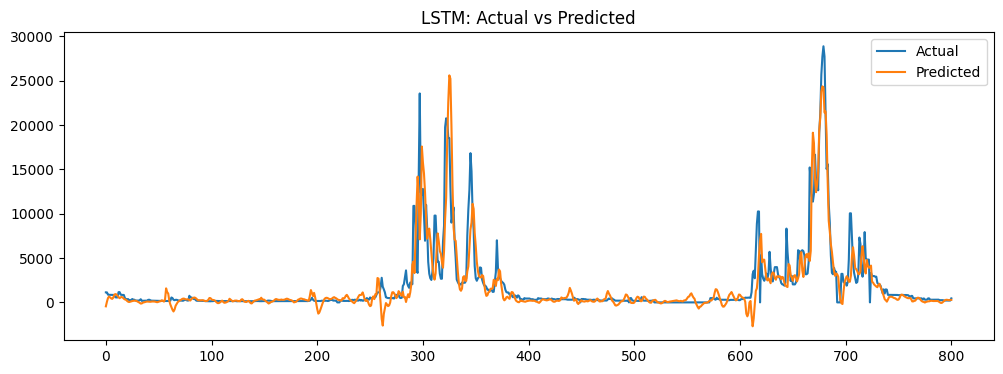

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("LSTM: Actual vs Predicted")
plt.show()

# Transformer

In [ ]:
from tensorflow.keras.layers import Input, Dense, LayerNormalization, MultiHeadAttention, Dropout, GlobalAveragePooling1D
from tensorflow.keras.models import Model

inputs = Input(shape=(window, X_seq.shape[2]))

# Attention block
x = MultiHeadAttention(num_heads=4, key_dim=32)(inputs, inputs)
x = LayerNormalization()(x)

# Feedforward
x = Dense(64, activation='relu')(x)
x = Dropout(0.1)(x)

# Pooling
x = GlobalAveragePooling1D()(x)

# Output
outputs = Dense(1)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='mse'
)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0044 - val_loss: 0.0011
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0024 - val_loss: 2.4402e-04
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0019 - val_loss: 3.4040e-04
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0015 - val_loss: 2.8571e-04
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0015 - val_loss: 1.7623e-04
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 4.2699e-04
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 7.5213e-04
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0013 - val_loss: 1.9027e-04
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 2.5475e-04
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0011 - val_loss: 8.2688e-04
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0012 - val_loss: 3.2151e-04
Epoch 12/20
91/91 ━━━━━━━━━━━━━━

In [ ]:
y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
rmse_tf = np.sqrt(mean_squared_error(y_test_actual, y_pred))
nse_tf = NSE(y_test_actual.flatten(), y_pred.flatten())

print("RMSE:", rmse_tf)
print("NSE:", nse_tf)

RMSE: 2500.1945639818077
NSE: 0.585087697156608
